# Libriaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Checking our dataset

In [2]:
df=pd.read_excel('Y:/datasets/cleaned_dataset_yeganeh-malakuti.xlsx')

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         60 non-null     int64         
 1   first_name          60 non-null     object        
 2   gender              60 non-null     object        
 3   age                 60 non-null     int64         
 4   city                60 non-null     object        
 5   province            60 non-null     object        
 6   signup_date         60 non-null     datetime64[ns]
 7   membership_tier     60 non-null     object        
 8   purchase_count      60 non-null     int64         
 9   avg_order_value     60 non-null     float64       
 10  total_spending      60 non-null     float64       
 11  last_purchase_days  60 non-null     int64         
 12  payment_method      60 non-null     object        
 13  device              60 non-null     object        
 

,customer_id,age,signup_date,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,60.000000,60.000000,60,60.000000,60.000000,60.000000,60.000000,54.000000,60.000000
mean,1030.500000,43.700000,2023-02-03 14:00:00,17.383333,213.156500,3366.428833,198.600000,4.037037,2.983333
min,1001.000000,19.000000,2021-02-23 00:00:00,0.000000,27.630000,0.000000,3.000000,0.000000,1.000000
25%,1015.750000,31.750000,2021-12-06 12:00:00,10.750000,108.137500,1167.035000,134.250000,2.000000,2.000000
50%,1030.500000,45.000000,2022-08-15 00:00:00,17.000000,165.435000,2128.690000,203.000000,4.000000,3.000000
75%,1045.250000,58.000000,2024-06-14 12:00:00,24.500000,324.107500,4213.117500,273.750000,6.750000,4.000000
max,1060.000000,65.000000,2025-09-09 00:00:00,35.000000,449.810000,14354.340000,365.000000,8.000000,5.000000
std,17.464249,13.946994,NaN,10.149880,130.509923,3235.132979,97.843043,2.684427,1.431979


# Customer Analysis

In [4]:
analysis_df = df.dropna(
    subset=["gender", "age", "membership_tier", "device", "payment_method"]
).copy()

In [5]:
age_bins = [0, 24, 34, 44, 54, 64, np.inf]
age_labels = [
    "Under 25",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

analysis_df["age_group"] = pd.cut(
    analysis_df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

In [6]:
profile_summary = pd.Series({
    "Number of Customers": analysis_df["customer_id"].nunique(),
    "Average Age": round(analysis_df["age"].mean(), 1),
    "Median Age": analysis_df["age"].median(),
    "Most Common Gender": analysis_df["gender"].mode()[0],
    "Most Common Membership Tier": analysis_df["membership_tier"].mode()[0],
    "Most Common Device": analysis_df["device"].mode()[0],
    "Most Common Payment Method": analysis_df["payment_method"].mode()[0]
})

display(profile_summary)

Number of Customers                       60
Average Age                             43.7
Median Age                              45.0
Most Common Gender                         M
Most Common Membership Tier             Gold
Most Common Device                   Android
Most Common Payment Method     Online Wallet
dtype: object

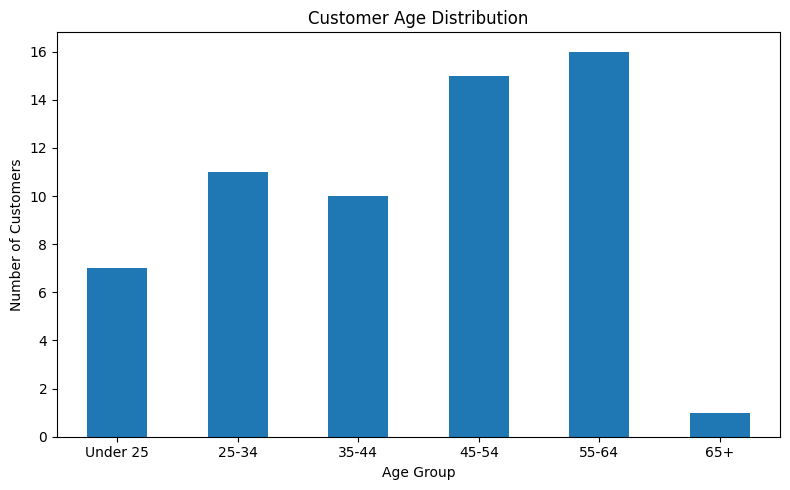

In [7]:
age_counts = (
    analysis_df["age_group"]
    .value_counts(sort=False)
)

age_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
def plot_bar_chart(column, title):

    (
        analysis_df[column]
        .value_counts()
        .sort_values(ascending=True)
        .plot(
            kind="barh",
            figsize=(8, 4.5)
        )
    )

    plt.title(title)
    plt.xlabel("Number of Customers")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

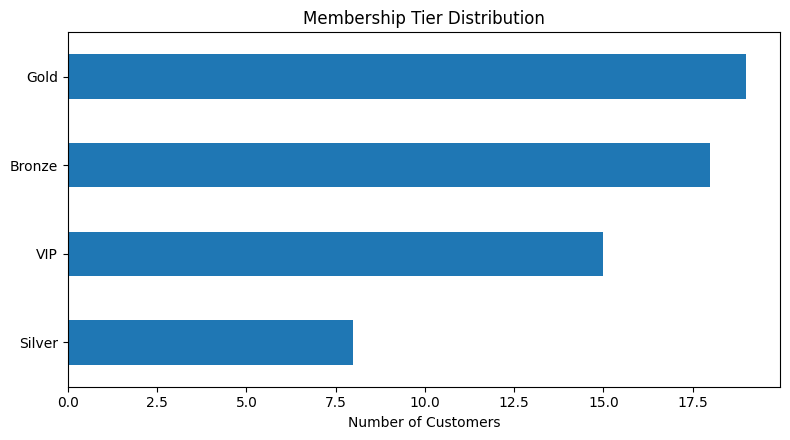

In [9]:
plot_bar_chart(
    "membership_tier",
    "Membership Tier Distribution"
)

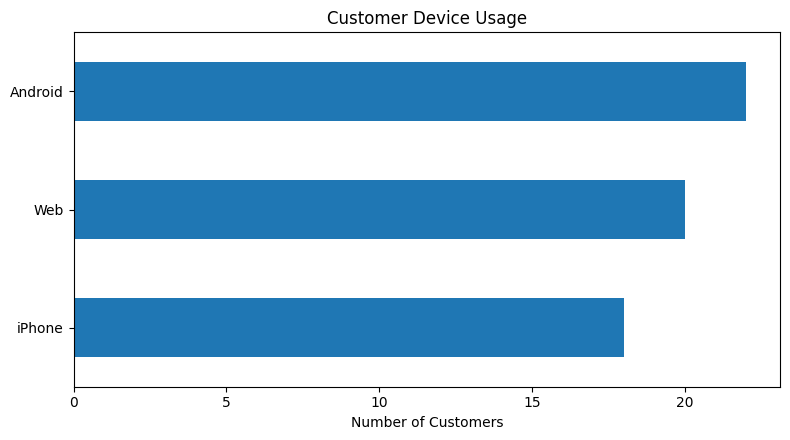

In [10]:
plot_bar_chart(
    "device",
    "Customer Device Usage"
)

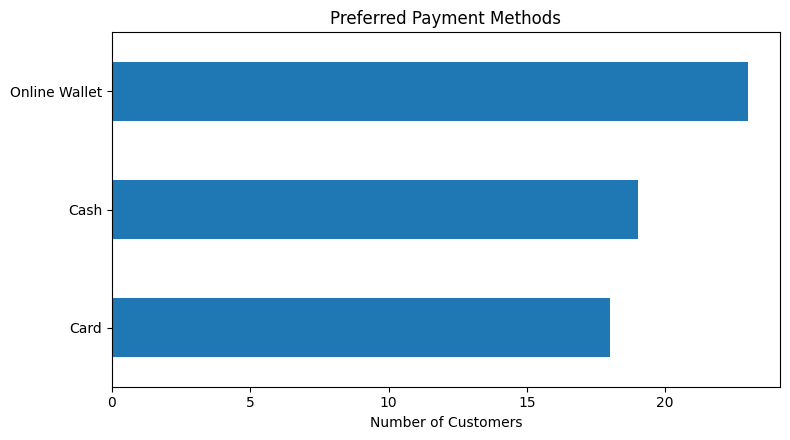

In [11]:
plot_bar_chart(
    "payment_method",
    "Preferred Payment Methods"
)

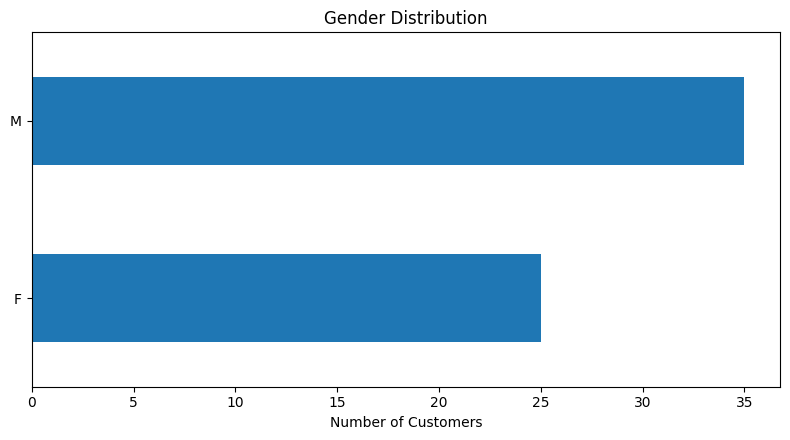

In [12]:
plot_bar_chart(
    "gender",
    "Gender Distribution"
)

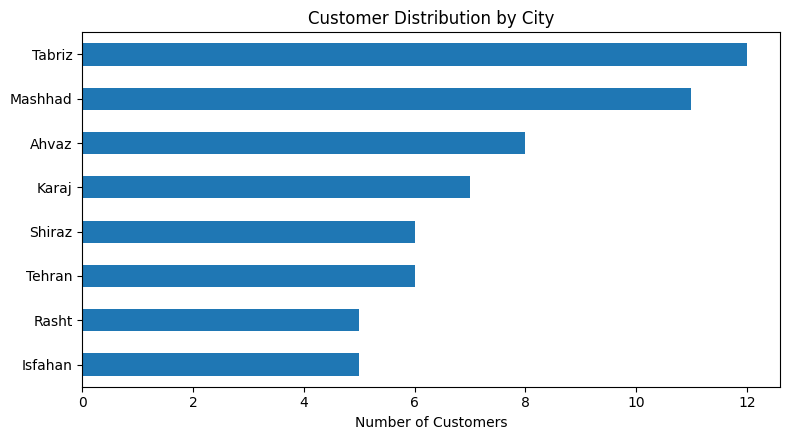

In [13]:
plot_bar_chart(
    "city",
    "Customer Distribution by City"
)

# City and Province Analysis

In [14]:
location_df = df.dropna(
    subset=[
        "province",
        "city",
        "customer_id",
        "total_spending",
        "purchase_count",
        "avg_order_value",
        "satisfaction_score"
    ]
).copy()


In [15]:
city_summary = (
    location_df
    .groupby(["province", "city"], as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_customer_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

# Keep only cities with at least 3 customers
city_summary = city_summary[
    city_summary["customer_count"] >= 3
].copy()

In [16]:
top_cities = (
    city_summary
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

display(
    top_cities.sort_values(
        "total_revenue",
        ascending=False
    )
)


,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,43197.58,3927.052727,22.636364,210.508182,2.909091
1,East Azerbaijan,Tabriz,12,36192.49,3016.040833,15.750000,238.901667,3.000000
0,Alborz,Karaj,7,26189.81,3741.401429,16.000000,211.440000,2.857143
6,Khuzestan,Ahvaz,8,23384.78,2923.097500,13.875000,216.531250,3.500000
4,Isfahan,Isfahan,5,21975.32,4395.064000,19.800000,212.680000,4.400000
2,Fars,Shiraz,6,20715.92,3452.653333,16.333333,180.983333,2.000000
3,Gilan,Rasht,5,15168.54,3033.708000,16.400000,241.554000,2.600000
7,Tehran,Tehran,6,15161.29,2526.881667,17.166667,172.930000,2.666667


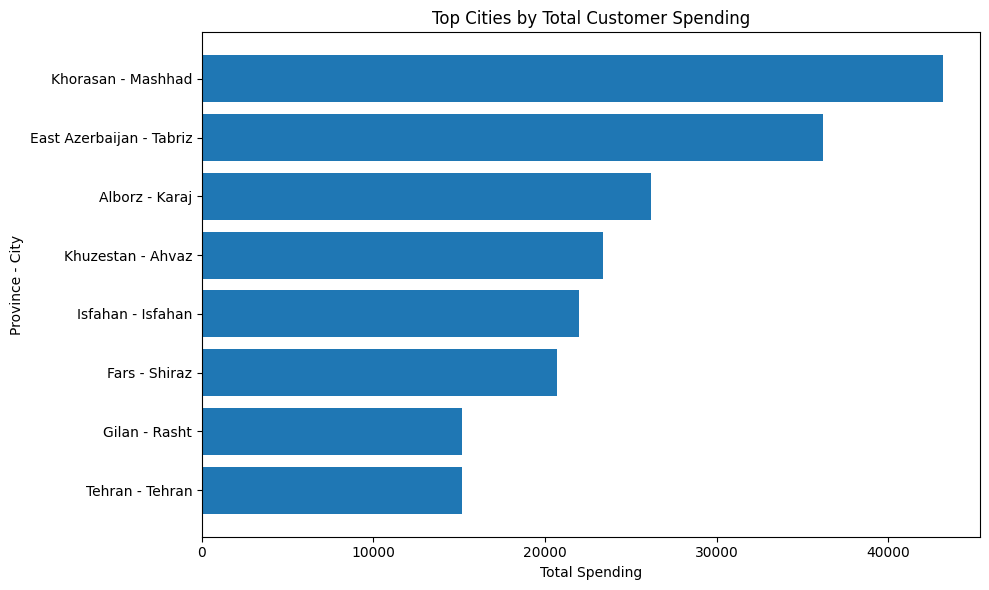

In [17]:
city_labels = (
    top_cities["province"]
    + " - "
    + top_cities["city"]
)

plt.figure(figsize=(10,6))

plt.barh(
    city_labels,
    top_cities["total_revenue"]
)

plt.title("Top Cities by Total Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Province - City")

plt.tight_layout()
plt.show()



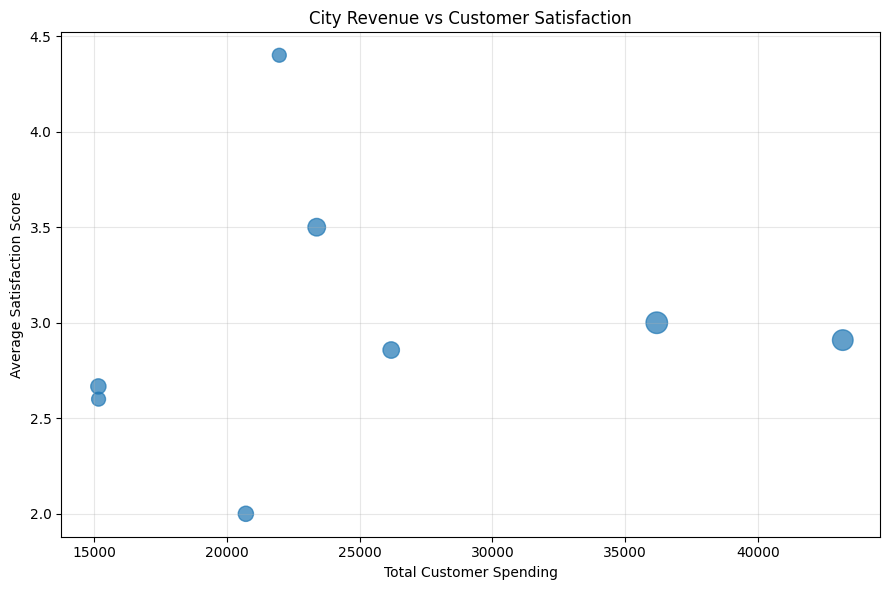

In [18]:
plt.figure(figsize=(9,6))

plt.scatter(
    city_summary["total_revenue"],
    city_summary["avg_satisfaction"],
    s=city_summary["customer_count"] * 20,
    alpha=0.7
)

plt.title("City Revenue vs Customer Satisfaction")
plt.xlabel("Total Customer Spending")
plt.ylabel("Average Satisfaction Score")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
recommended_city = (
    city_summary
    .sort_values(
        by=[
            "total_revenue",
            "avg_satisfaction",
            "customer_count"
        ],
        ascending=False
    )
    .head(1)
)

display(recommended_city)

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,43197.58,3927.052727,22.636364,210.508182,2.909091


# Customer loyalty planning

In [20]:
loyalty_df = df.dropna(
    subset=[
        "customer_id",
        "first_name",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
).copy()

In [21]:
score_columns = [
    "purchase_count",
    "total_spending",
    "satisfaction_score"
]

for column in score_columns:

    minimum = loyalty_df[column].min()
    maximum = loyalty_df[column].max()

    if minimum == maximum:
        loyalty_df[f"{column}_score"] = 1

    else:
        loyalty_df[f"{column}_score"] = (
            (loyalty_df[column] - minimum)
            / (maximum - minimum)
        )


In [22]:
recency_min = loyalty_df["last_purchase_days"].min()
recency_max = loyalty_df["last_purchase_days"].max()

if recency_min == recency_max:

    loyalty_df["recency_score"] = 1

else:

    loyalty_df["recency_score"] = 1 - (
        (
            loyalty_df["last_purchase_days"]
            - recency_min
        )
        / (recency_max - recency_min)
    )


In [23]:
loyalty_df["loyalty_score"] = (

    0.35 * loyalty_df["total_spending_score"]

    + 0.30 * loyalty_df["purchase_count_score"]

    + 0.20 * loyalty_df["recency_score"]

    + 0.15 * loyalty_df["satisfaction_score_score"]

)

In [24]:

top_loyal_customers = (
    loyalty_df
    .nlargest(10, "loyalty_score")
    [
        [
            "customer_id",
            "first_name",
            "membership_tier",
            "purchase_count",
            "total_spending",
            "last_purchase_days",
            "satisfaction_score",
            "loyalty_score"
        ]
    ]
)

display(top_loyal_customers)

,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,loyalty_score
56,1057,Maryam,Bronze,31,13532.74,82,4,0.864535
43,1044,Mina,Gold,33,14354.34,165,2,0.780854
58,1059,Ali,Gold,31,8898.55,224,5,0.710587
8,1009,Kimia,Silver,34,11615.42,232,2,0.685627
3,1004,Sina,Gold,23,6121.45,40,4,0.638459
11,1012,Arash,Gold,27,11731.50,224,2,0.632877
32,1033,Neda,VIP,24,5521.20,112,5,0.630116
13,1014,Reza,VIP,31,3353.89,97,4,0.608058
22,1023,Ali,Bronze,31,3851.44,170,4,0.579858
16,1017,Parsa,VIP,30,3239.40,135,4,0.575701


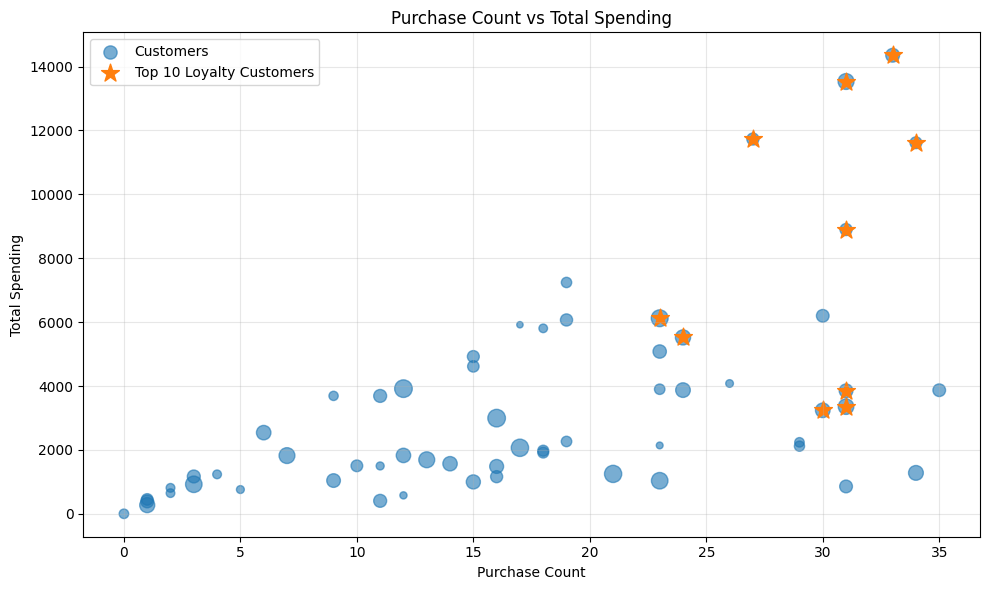

In [25]:
plt.figure(figsize=(10,6))


plt.scatter(

    loyalty_df["purchase_count"],

    loyalty_df["total_spending"],

    s=(loyalty_df["recency_score"] + 0.15) * 140,

    alpha=0.6,

    label="Customers"

)


plt.scatter(

    top_loyal_customers["purchase_count"],

    top_loyal_customers["total_spending"],

    s=180,

    marker="*",

    label="Top 10 Loyalty Customers"

)

plt.title("Purchase Count vs Total Spending")

plt.xlabel("Purchase Count")

plt.ylabel("Total Spending")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Customer inactivity risk

In [26]:
risk_df = df.dropna(
    subset=[
        "customer_id",
        "first_name",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
).copy()

In [27]:
# High-value customers
spending_threshold = risk_df["total_spending"].quantile(0.75)

# Regular purchasers
purchase_threshold = risk_df["purchase_count"].median()

# Customers inactive for a long time
inactivity_threshold = risk_df["last_purchase_days"].quantile(0.75)

In [28]:
risk_df["at_risk"] = (

    (risk_df["total_spending"] >= spending_threshold)

    & (risk_df["purchase_count"] >= purchase_threshold)

    & (risk_df["last_purchase_days"] >= inactivity_threshold)

)

In [29]:
at_risk_customers = (

    risk_df.loc[
        risk_df["at_risk"],
        [
            "customer_id",
            "first_name",
            "membership_tier",
            "purchase_count",
            "total_spending",
            "last_purchase_days",
            "satisfaction_score"
        ]
    ]

    .sort_values(
        by=[
            "total_spending",
            "last_purchase_days"
        ],
        ascending=False
    )

)

display(at_risk_customers)

print(f"Number of At-Risk Customers: {len(at_risk_customers)}")

,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
9,1010,Arash,Silver,19,7241.47,276,1
34,1035,Arash,Bronze,17,5918.21,365,3
52,1053,Sina,Gold,18,5805.54,320,1


Number of At-Risk Customers: 3


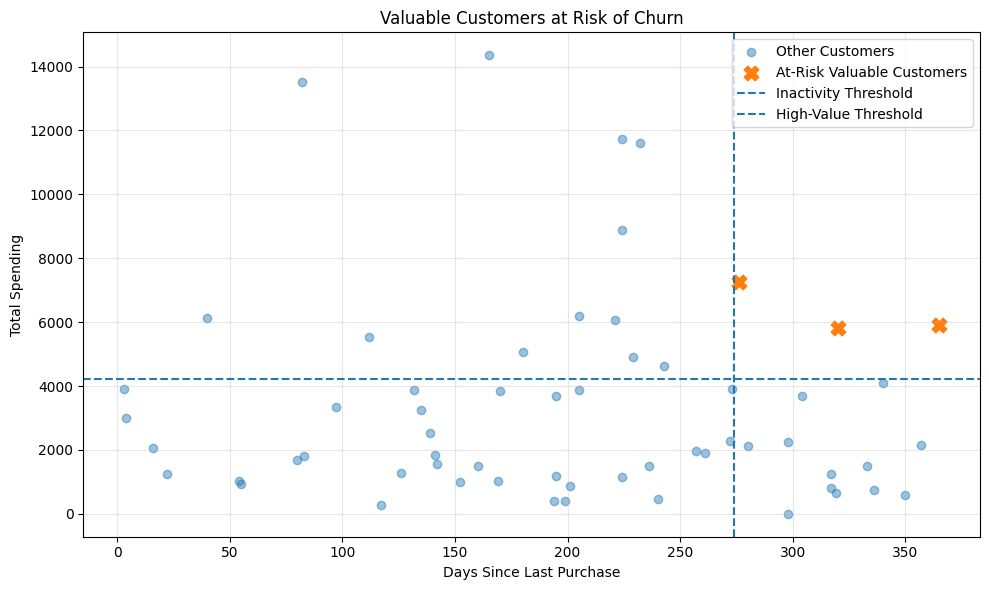

In [30]:
plt.figure(figsize=(10,6))


plt.scatter(

    risk_df.loc[
        ~risk_df["at_risk"],
        "last_purchase_days"
    ],

    risk_df.loc[
        ~risk_df["at_risk"],
        "total_spending"
    ],

    alpha=0.45,

    label="Other Customers"

)


plt.scatter(

    risk_df.loc[
        risk_df["at_risk"],
        "last_purchase_days"
    ],

    risk_df.loc[
        risk_df["at_risk"],
        "total_spending"
    ],

    marker="X",

    s=110,

    label="At-Risk Valuable Customers"

)



plt.axvline(
    inactivity_threshold,
    linestyle="--",
    label="Inactivity Threshold"
)

plt.axhline(
    spending_threshold,
    linestyle="--",
    label="High-Value Threshold"
)

plt.title("Valuable Customers at Risk of Churn")

plt.xlabel("Days Since Last Purchase")

plt.ylabel("Total Spending")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Discount, Device, and Payment method

In [31]:
factor_df = df.dropna(
    subset=[
        "customer_id",
        "discount_used",
        "device",
        "payment_method",
        "total_spending",
        "purchase_count",
        "avg_order_value",
        "returned_items",
        "satisfaction_score"
    ]
).copy()

In [32]:
discount_summary = (
    factor_df
    .groupby("discount_used", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_total_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_returned_items=("returned_items", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

display(discount_summary)

,discount_used,customer_count,avg_total_spending,avg_purchase_count,avg_order_value,avg_returned_items,avg_satisfaction
0,No,31,4046.150000,18.838710,212.927742,4.225806,2.903226
1,Yes,23,3172.977391,19.521739,185.506957,3.782609,3.217391


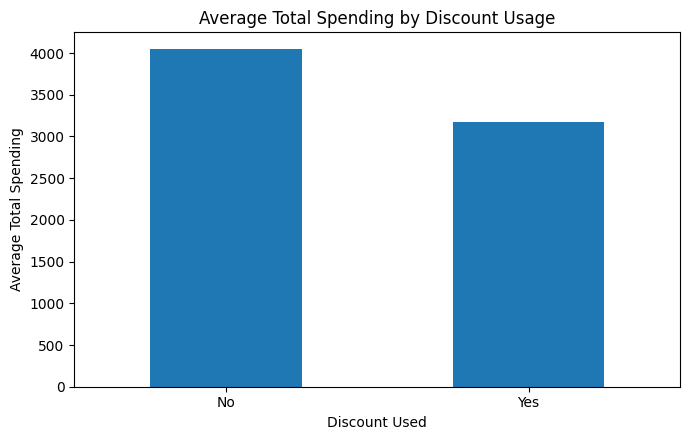

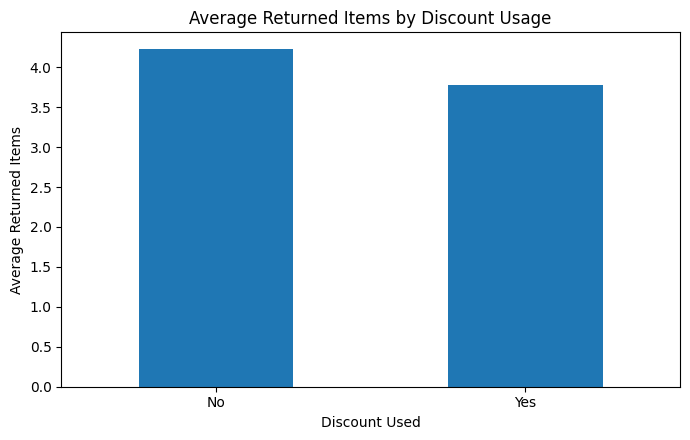

In [33]:
discount_metrics = {
    "avg_total_spending": (
        "Average Total Spending by Discount Usage",
        "Average Total Spending"
    ),
    "avg_returned_items": (
        "Average Returned Items by Discount Usage",
        "Average Returned Items"
    )
}

for column, (title, ylabel) in discount_metrics.items():

    discount_summary.plot(
        x="discount_used",
        y=column,
        kind="bar",
        legend=False,
        figsize=(7,4.5)
    )

    plt.title(title)
    plt.xlabel("Discount Used")
    plt.ylabel(ylabel)
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

,customer_count,avg_spending
device,,
Web,17,3321.827647
Android,20,3758.789500
iPhone,17,3927.192353


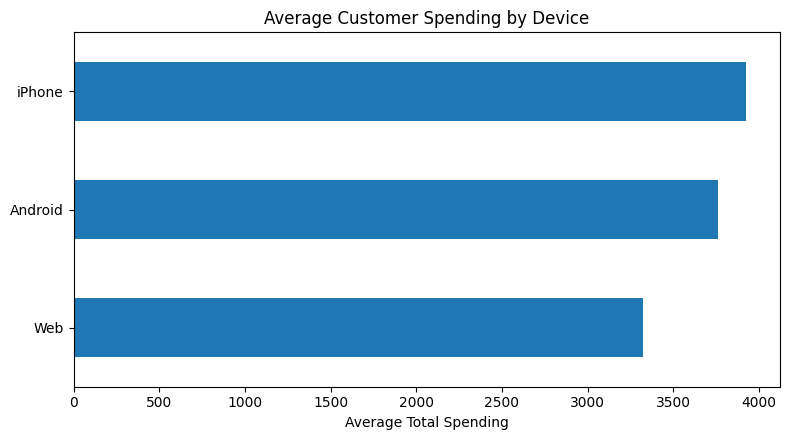

,customer_count,avg_spending
payment_method,,
Cash,17,3460.393529
Online Wallet,20,3489.204000
Card,17,4105.785882


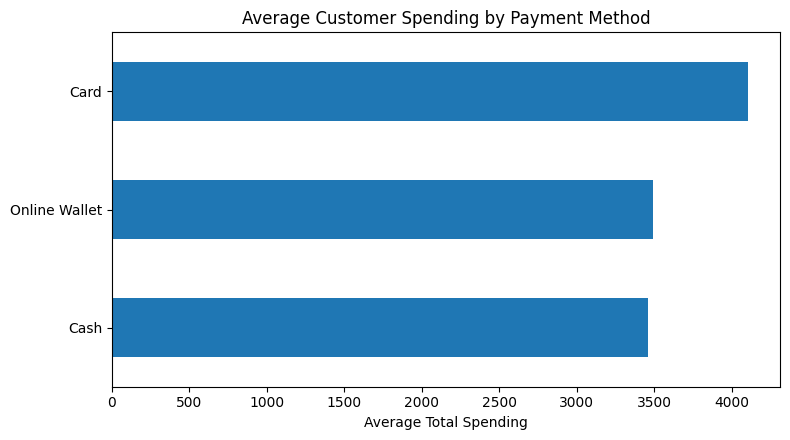

In [34]:
analysis_factors = {
    "device": "Average Customer Spending by Device",
    "payment_method": "Average Customer Spending by Payment Method"
}

for column, title in analysis_factors.items():

    summary = (

        factor_df

        .groupby(column)["total_spending"]

        .agg(
            customer_count="count",
            avg_spending="mean"
        )

        .query("customer_count >= 3")

        .sort_values("avg_spending")

    )

    display(summary)

    summary["avg_spending"].plot(
        kind="barh",
        figsize=(8,4.5)
    )

    plt.title(title)
    plt.xlabel("Average Total Spending")
    plt.ylabel("")

    plt.tight_layout()
    plt.show()

# 5 Min report

In [35]:
kpi_summary = pd.Series({

    "Unique Customers":
        df["customer_id"].nunique(),

    "Total Customer Spending":
        round(df["total_spending"].sum(), 2),

    "Average Customer Spending":
        round(df["total_spending"].mean(), 2),

    "Average Purchase Count":
        round(df["purchase_count"].mean(), 2),

    "Average Satisfaction Score":
        round(df["satisfaction_score"].mean(), 2),

    "Total Returned Items":
        df["returned_items"].sum()

}, name="Value")

display(kpi_summary)

Unique Customers                  60.00
Total Customer Spending       201985.73
Average Customer Spending       3366.43
Average Purchase Count            17.38
Average Satisfaction Score         2.98
Total Returned Items             218.00
Name: Value, dtype: float64

In [37]:
top_10_customers = (
    loyalty_df
    .nlargest(10, "loyalty_score")
    .sort_values("loyalty_score")
)

display(top_10_customers)

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,...,payment_method,device,discount_used,returned_items,satisfaction_score,purchase_count_score,total_spending_score,satisfaction_score_score,recency_score,loyalty_score
16,1017,Parsa,M,49,Ahvaz,Khuzestan,2022-07-01,VIP,30,107.98,...,Cash,iPhone,No,8.0,4,0.857143,0.225674,0.75,0.635359,0.575701
22,1023,Ali,M,50,Mashhad,Khorasan,2024-05-02,Bronze,31,124.24,...,Card,Web,No,2.0,4,0.885714,0.268312,0.75,0.538674,0.579858
13,1014,Reza,M,35,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,...,Card,Android,No,5.0,4,0.885714,0.233650,0.75,0.740331,0.608058
32,1033,Neda,F,63,Tabriz,East Azerbaijan,2021-02-25,VIP,24,230.05,...,Card,Web,No,0.0,5,0.685714,0.384636,1.00,0.698895,0.630116
11,1012,Arash,M,51,Mashhad,Khorasan,2023-07-22,Gold,27,434.50,...,Online Wallet,iPhone,Yes,3.0,2,0.771429,0.817279,0.25,0.389503,0.632877
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,...,Card,Android,No,4.0,4,0.657143,0.426453,0.75,0.897790,0.638459
8,1009,Kimia,F,61,Karaj,Alborz,2021-05-14,Silver,34,341.63,...,Card,Web,No,8.0,2,0.971429,0.809192,0.25,0.367403,0.685627
58,1059,Ali,M,57,Isfahan,Isfahan,2023-09-05,Gold,31,287.05,...,Online Wallet,iPhone,Yes,0.0,5,0.885714,0.619921,1.00,0.389503,0.710587
43,1044,Mina,F,64,Shiraz,Fars,2024-07-27,Gold,33,434.98,...,Card,Android,No,7.0,2,0.942857,1.000000,0.25,0.552486,0.780854
56,1057,Maryam,F,58,Ahvaz,Khuzestan,2024-06-11,Bronze,31,436.54,...,Cash,iPhone,No,4.0,4,0.885714,0.942763,0.75,0.781768,0.864535


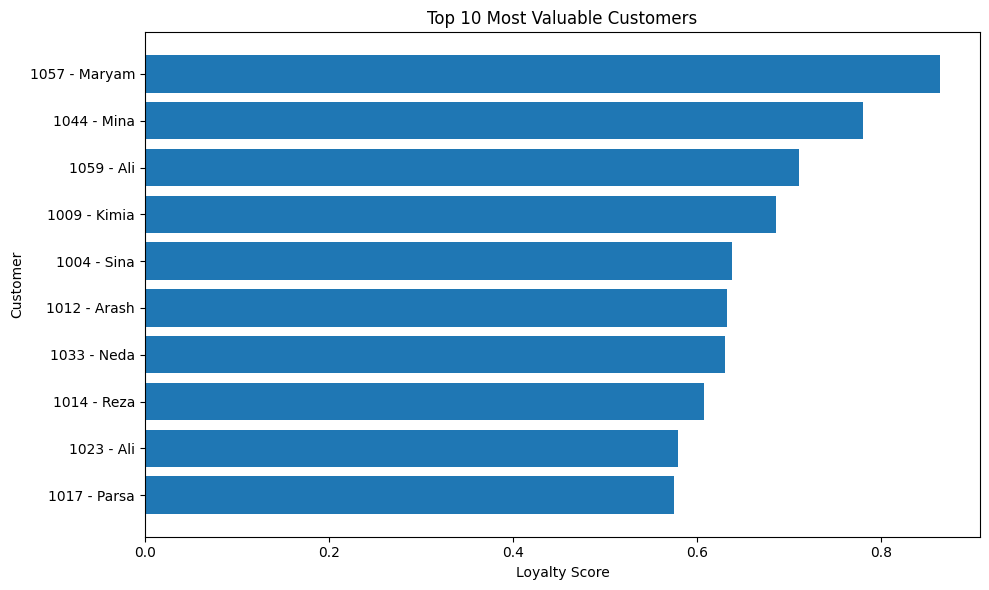

In [38]:
plt.figure(figsize=(10, 6))

labels = (
    top_10_customers["customer_id"].astype(str)
    + " - "
    + top_10_customers["first_name"]
)

plt.barh(
    labels,
    top_10_customers["loyalty_score"]
)

plt.title("Top 10 Most Valuable Customers")
plt.xlabel("Loyalty Score")
plt.ylabel("Customer")

plt.tight_layout()
plt.show()

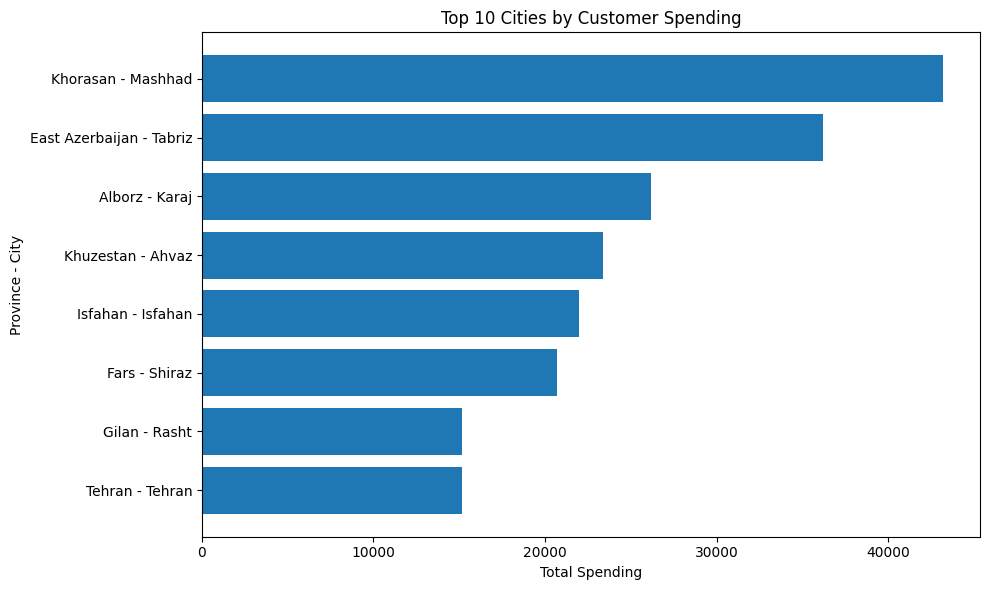

In [39]:
top_cities = (
    city_summary
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

city_labels = (
    top_cities["province"]
    + " - "
    + top_cities["city"]
)

plt.figure(figsize=(10,6))

plt.barh(
    city_labels,
    top_cities["total_revenue"]
)

plt.title("Top 10 Cities by Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Province - City")

plt.tight_layout()
plt.show()


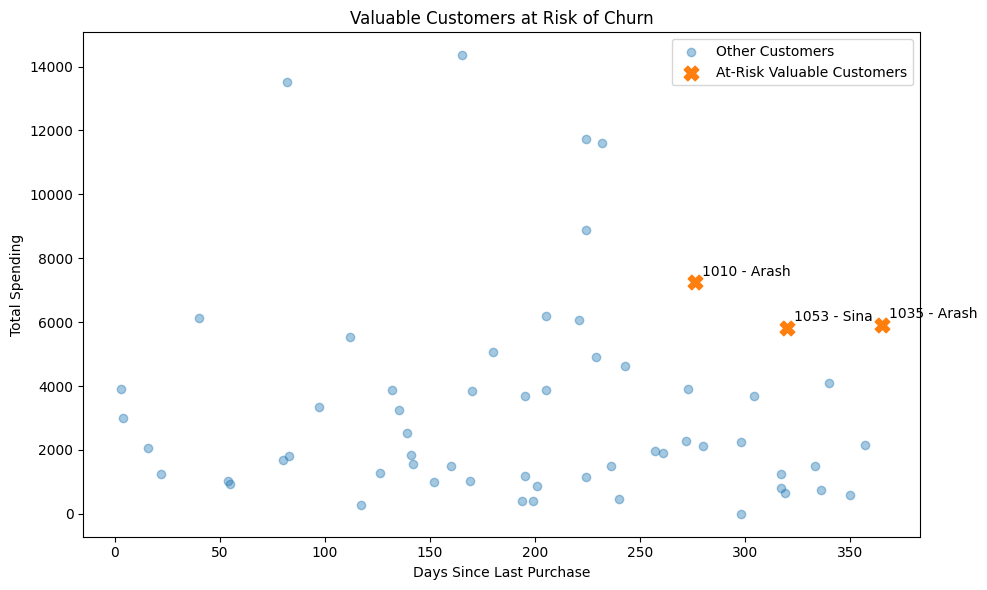

In [43]:
plt.figure(figsize=(10,6))

plt.scatter(

    risk_df.loc[
        ~risk_df["at_risk"],
        "last_purchase_days"
    ],

    risk_df.loc[
        ~risk_df["at_risk"],
        "total_spending"
    ],

    alpha=0.4,

    label="Other Customers"

)

plt.scatter(

    risk_df.loc[
        risk_df["at_risk"],
        "last_purchase_days"
    ],

    risk_df.loc[
        risk_df["at_risk"],
        "total_spending"
    ],

    marker="X",

    s=110,

    label="At-Risk Valuable Customers"

)
for _, customer in risk_df[risk_df["at_risk"]].iterrows():

    plt.annotate(
        f'{customer["customer_id"]} - {customer["first_name"]}',
        (
            customer["last_purchase_days"],
            customer["total_spending"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Valuable Customers at Risk of Churn")

plt.xlabel("Days Since Last Purchase")

plt.ylabel("Total Spending")

plt.legend()

plt.tight_layout()

plt.show()


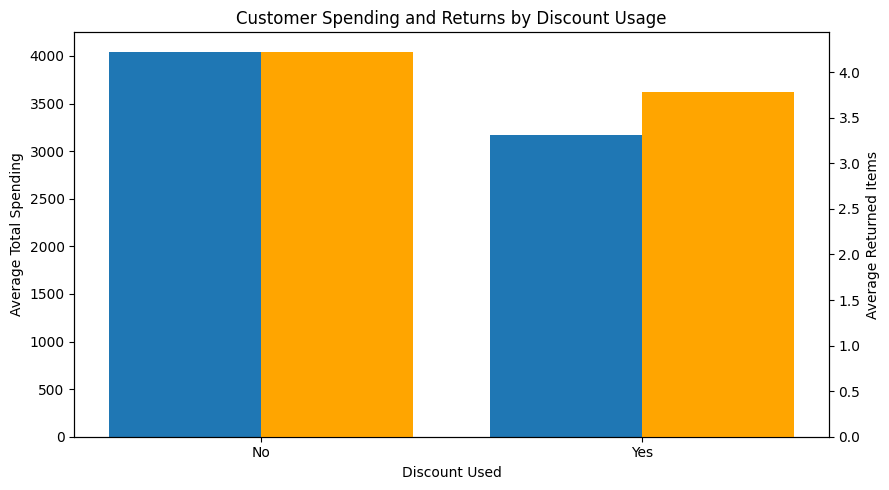

In [55]:
discount_summary = (
    factor_df
    .groupby("discount_used")
    .agg(
        avg_total_spending=("total_spending", "mean"),
        avg_returned_items=("returned_items", "mean")
    )
)


discount_summary = discount_summary.reindex(["No", "Yes"])


x = range(len(discount_summary))

fig, ax1 = plt.subplots(figsize=(9, 5))


ax1.bar(
    [i - 0.2 for i in x],
    discount_summary["avg_total_spending"],
    width=0.4,
    label="Average Total Spending"
)

ax1.set_xlabel("Discount Used")
ax1.set_ylabel("Average Total Spending")
ax1.set_xticks(list(x))
ax1.set_xticklabels(discount_summary.index)


ax2 = ax1.twinx()

ax2.bar(
    [i + 0.2 for i in x],
    discount_summary["avg_returned_items"],
    width=0.4,
    color="orange",
    label="Average Returned Items"
)

ax2.set_ylabel("Average Returned Items")

plt.title("Customer Spending and Returns by Discount Usage")

fig.tight_layout()
plt.show()